In [301]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bank-customer-churn-dataset/Bank Customer Churn Prediction.csv


In [302]:
df = pd.read_csv('/kaggle/input/bank-customer-churn-dataset/Bank Customer Churn Prediction.csv')
df.sample(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
7767,15748660,561,Germany,Female,49,1,102025.32,1,1,0,133051.64,1
6151,15761525,727,Spain,Female,31,10,96997.09,2,0,0,76614.04,0
7398,15577771,453,Germany,Female,40,1,111524.49,1,1,1,120373.84,1
2255,15681506,478,Spain,Male,43,1,0.00,2,1,1,197916.43,0
9554,15593778,779,France,Female,29,3,46388.16,3,1,0,127939.26,1
5031,15680517,769,Germany,Female,34,7,137239.17,1,1,1,71379.92,1
5310,15624744,622,Germany,Male,42,9,115766.26,1,0,0,72155.85,1
2639,15581036,712,Germany,Female,40,3,109308.79,2,1,0,120158.72,1
2440,15790659,701,Spain,Male,59,7,0.00,2,0,1,27597.59,0
2950,15744919,734,Spain,Female,37,0,152760.24,1,1,1,48990.50,0


In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [304]:
correlations = df.corr(numeric_only = True)['churn']
correlations.sort_values()

active_member      -0.156128
products_number    -0.047820
credit_score       -0.027094
tenure             -0.014001
credit_card        -0.007138
customer_id        -0.006248
estimated_salary    0.012097
balance             0.118533
age                 0.285323
churn               1.000000
Name: churn, dtype: float64

In [305]:
import seaborn as sns


In [306]:
df.drop(columns = ['customer_id' , 'products_number'] , inplace = True)

In [307]:
df.isnull().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [308]:
df.head()

,credit_score,country,gender,age,tenure,balance,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,1,0,113931.57,1
3,699,France,Female,39,1,0.00,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,79084.10,0


In [309]:
df.shape

(10000, 10)

In [310]:
df['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [311]:
df['gender'].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

In [312]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

gender_encoder = OneHotEncoder(drop='first' , sparse_output = False)
country_encoder = OneHotEncoder(drop = None , sparse_output = False)

encoder = ColumnTransformer(
    transformers = [
        ('gender_encode' , gender_encoder , ['gender']) , 
        ('country_encode' , country_encoder , ['country'])
    ] , 
    remainder = 'passthrough'
)

x_transformed = encoder.fit_transform(df)

In [313]:
x_transformed

array([[0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        1.0134888e+05, 1.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        1.1254258e+05, 0.0000000e+00],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.1393157e+05, 1.0000000e+00],
       ...,
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        4.2085580e+04, 1.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        9.2888520e+04, 1.0000000e+00],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        3.8190780e+04, 0.0000000e+00]])

In [314]:
gender_cols = encoder.named_transformers_['gender_encode'].get_feature_names_out(['gender'])
country_cols = encoder.named_transformers_['country_encode'].get_feature_names_out(['country'])
passthrough_cols = [col for col in df.columns if col not in ['gender' , 'country']]
final_cols = list(gender_cols) + list(country_cols) + passthrough_cols
final_cols

['gender_Male',
 'country_France',
 'country_Germany',
 'country_Spain',
 'credit_score',
 'age',
 'tenure',
 'balance',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn']

In [315]:
df = pd.DataFrame(x_transformed , columns = final_cols)
df

,gender_Male,country_France,country_Germany,country_Spain,credit_score,age,tenure,balance,credit_card,active_member,estimated_salary,churn
0,0.0,1.0,0.0,0.0,619.0,42.0,2.0,0.00,1.0,1.0,101348.88,1.0
1,0.0,0.0,0.0,1.0,608.0,41.0,1.0,83807.86,0.0,1.0,112542.58,0.0
2,0.0,1.0,0.0,0.0,502.0,42.0,8.0,159660.80,1.0,0.0,113931.57,1.0
3,0.0,1.0,0.0,0.0,699.0,39.0,1.0,0.00,0.0,0.0,93826.63,0.0
4,0.0,0.0,0.0,1.0,850.0,43.0,2.0,125510.82,1.0,1.0,79084.10,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,1.0,0.0,0.0,771.0,39.0,5.0,0.00,1.0,0.0,96270.64,0.0
9996,1.0,1.0,0.0,0.0,516.0,35.0,10.0,57369.61,1.0,1.0,101699.77,0.0
9997,0.0,1.0,0.0,0.0,709.0,36.0,7.0,0.00,0.0,1.0,42085.58,1.0
9998,1.0,0.0,1.0,0.0,772.0,42.0,3.0,75075.31,1.0,0.0,92888.52,1.0


In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender_Male       10000 non-null  float64
 1   country_France    10000 non-null  float64
 2   country_Germany   10000 non-null  float64
 3   country_Spain     10000 non-null  float64
 4   credit_score      10000 non-null  float64
 5   age               10000 non-null  float64
 6   tenure            10000 non-null  float64
 7   balance           10000 non-null  float64
 8   credit_card       10000 non-null  float64
 9   active_member     10000 non-null  float64
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  float64
dtypes: float64(12)
memory usage: 937.6 KB


In [317]:
X = df.drop(columns = ['churn'])
y = df['churn']
y

0       1.0
1       0.0
2       1.0
3       0.0
4       0.0
       ... 
9995    0.0
9996    0.0
9997    1.0
9998    1.0
9999    0.0
Name: churn, Length: 10000, dtype: float64

In [318]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [319]:
from sklearn.preprocessing import StandardScaler 
categorical_cols = ['gender', 'country']
numerical_cols = ['estimated_salary', 'balance', 'tenure', 'age', 'credit_score']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ] , remainder = 'passthrough'
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [320]:
X_train_processed

array([[ 1.36766974, -1.21847056,  0.34567966, ...,  0.        ,
         1.        ,  1.        ],
       [ 1.6612541 ,  0.69683765, -0.3483691 , ...,  0.        ,
         1.        ,  1.        ],
       [-0.25280688,  0.61862909, -0.69539349, ...,  1.        ,
         1.        ,  0.        ],
       ...,
       [-0.1427649 , -1.21847056, -1.38944225, ...,  0.        ,
         0.        ,  0.        ],
       [-0.05082558,  1.8272593 ,  1.03972843, ...,  0.        ,
         1.        ,  0.        ],
       [-0.81456811,  1.1497197 , -1.38944225, ...,  0.        ,
         1.        ,  1.        ]])

In [321]:
X_train_processed.shape

(8000, 11)

In [322]:
X_train_processed

array([[ 1.36766974, -1.21847056,  0.34567966, ...,  0.        ,
         1.        ,  1.        ],
       [ 1.6612541 ,  0.69683765, -0.3483691 , ...,  0.        ,
         1.        ,  1.        ],
       [-0.25280688,  0.61862909, -0.69539349, ...,  1.        ,
         1.        ,  0.        ],
       ...,
       [-0.1427649 , -1.21847056, -1.38944225, ...,  0.        ,
         0.        ,  0.        ],
       [-0.05082558,  1.8272593 ,  1.03972843, ...,  0.        ,
         1.        ,  0.        ],
       [-0.81456811,  1.1497197 , -1.38944225, ...,  0.        ,
         1.        ,  1.        ]])

In [323]:
type(X_train_processed)

numpy.ndarray

In [324]:
y_train = np.array(y_train)

In [325]:
print(y_train.dtype)
print(X_train_processed.dtype)

float64
float64


In [326]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape = (11,)),
    layers.Dense(11 , activation = 'relu'), 
    layers.Dense(11 , activation = 'relu') , 
    layers.Dense(1 , activation = 'sigmoid')
])

In [327]:
model.compile(
    optimizer = 'adam' , 
    loss = 'binary_crossentropy' , 
    metrics = ['accuracy']
)

In [328]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [329]:
history = model.fit(X_train_processed , y_train , batch_size = 50 , epochs = 100 , validation_split = 0.1 )

Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5732 - loss: 0.6727 - val_accuracy: 0.8037 - val_loss: 0.5118
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7875 - loss: 0.5075 - val_accuracy: 0.8037 - val_loss: 0.4530
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7910 - loss: 0.4595 - val_accuracy: 0.8225 - val_loss: 0.4228
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4379 - val_accuracy: 0.8275 - val_loss: 0.4119
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8087 - loss: 0.4366 - val_accuracy: 0.8263 - val_loss: 0.4067
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8145 - loss: 0.4279 - val_accuracy: 0.8325 - val_loss: 0.4048
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8220 - loss: 0.4191 - val_accuracy: 0.8375 - val_loss: 0.4010
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8254 - loss: 0.4130 - val_accu

In [330]:
history.history

{'accuracy': [0.710277795791626,
  0.7934722304344177,
  0.7958333492279053,
  0.8037499785423279,
  0.8093055486679077,
  0.8151388764381409,
  0.816944420337677,
  0.8187500238418579,
  0.8199999928474426,
  0.8208333253860474,
  0.8240277767181396,
  0.8276388645172119,
  0.8291666507720947,
  0.8305555582046509,
  0.8308333158493042,
  0.8326388597488403,
  0.8331944346427917,
  0.831944465637207,
  0.8336111307144165,
  0.8330555558204651,
  0.8349999785423279,
  0.8330555558204651,
  0.8340277671813965,
  0.835277795791626,
  0.8337500095367432,
  0.8358333110809326,
  0.835277795791626,
  0.8355555534362793,
  0.8344444632530212,
  0.8374999761581421,
  0.8355555534362793,
  0.8355555534362793,
  0.835694432258606,
  0.8366666436195374,
  0.8368055820465088,
  0.8362500071525574,
  0.8373610973358154,
  0.8368055820465088,
  0.8370833396911621,
  0.8361111283302307,
  0.8376389145851135,
  0.8373610973358154,
  0.8380555510520935,
  0.8388888835906982,
  0.8373610973358154,
  0.

In [336]:
y_pred = model.predict(X_test_processed)
y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[0.08493727],
       [0.11081573],
       [0.29787606],
       ...,
       [0.48319647],
       [0.05590442],
       [0.16688304]], dtype=float32)

In [337]:
y_pred = np.where(y_pred >= 0.5 , 1 , 0)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [338]:
np.unique(y_pred)

array([0, 1])

In [343]:
y_pred = np.array(y_pred , 'float64')
y_pred.dtype

dtype('float64')

In [345]:
y_test

6252    0.0
4684    0.0
1731    0.0
4742    0.0
4521    0.0
       ... 
6412    1.0
8285    0.0
7853    1.0
1095    1.0
6929    1.0
Name: churn, Length: 2000, dtype: float64

In [346]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.8405

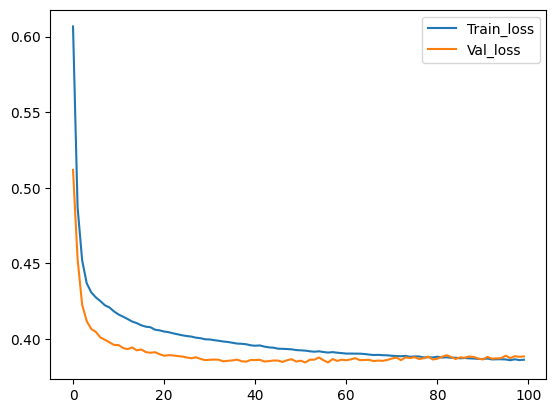

In [348]:
import matplotlib.pyplot as plt 

plt.plot(history.history['loss'] , label = 'Train_loss')
plt.plot(history.history['val_loss'] , label = 'Val_loss')
plt.legend()

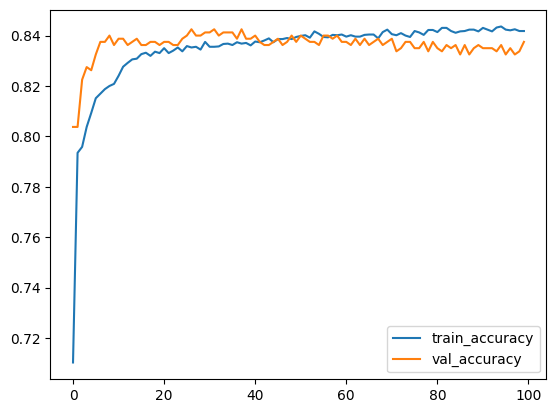

In [349]:
plt.plot(history.history['accuracy'] , label = 'train_accuracy')
plt.plot(history.history['val_accuracy'] , label = 'val_accuracy')
plt.legend()